In [1]:
import BioSimSpace as BSS

INFO:rdkit:Enabling RDKit 2025.03.6 jupyter extensions
INFO:numexpr.utils:Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:numexpr.utils:NumExpr defaulting to 16 threads.


## Holo: AM-7209 Open Conformation E23G - FF14SB Example

In [4]:
# Load the input protein files
mdm2_wt = BSS.IO.readMolecules("inputs/wt_am_open.amber.pdb")[0]
mdm2_mut = BSS.IO.readMolecules("inputs/e23g_am_open.amber.pdb")[0]

In [5]:
# Load the ligand
am_7209 = BSS.IO.readMolecules(["inputs/am_ligand.gro", "inputs/am_ligand.top"])[0]

In [7]:
# Parametrise the protein
mdm2_wt = BSS.Parameters.ff14SB(mdm2_wt, ensure_compatible=False).getMolecule()
mdm2_mut = BSS.Parameters.ff14SB(mdm2_mut, ensure_compatible=False).getMolecule()

In [8]:
# Determine the region of interest (ROI) for the mutation
roi = []
for i, res in enumerate(mdm2_wt.getResidues()):
    if res.name() != mdm2_mut.getResidues()[i].name():
        print(res, mdm2_mut.getResidues()[i])
        roi.append(res.index())

<BioSimSpace.Residue: name='GLU', molecule=12, index=18, nAtoms=15> <BioSimSpace.Residue: name='GLY', molecule=14, index=18, nAtoms=7>


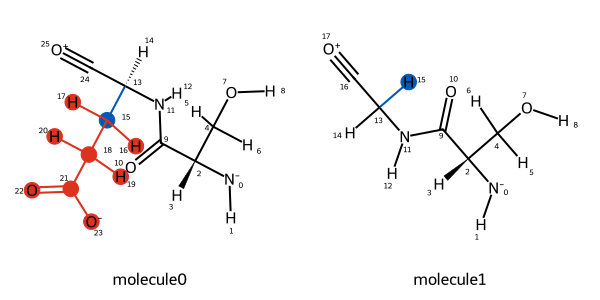

In [10]:
# Perform MCS alignment between wild-type and mutant protein and visualise the mapped atoms

mapping = BSS.Align.matchAtoms(molecule0=mdm2_wt, molecule1=mdm2_mut, roi=roi)

BSS.Align.viewMapping(mdm2_wt, mdm2_mut, mapping, roi=roi[0])

In [12]:
aligned_mol_a = BSS.Align.rmsdAlign(molecule0=mdm2_wt, molecule1=mdm2_mut, roi=roi)
merged = BSS.Align.merge(molecule0=aligned_mol_a, molecule1=mdm2_mut, mapping=mapping, roi=roi)

In [14]:
# Create a holo system
merged_system = merged + am_7209

In [15]:
# Solvate the merged system
# Initialize base shape to extract the correct angles for a truncated octahedron
_, angles = BSS.Box.truncatedOctahedron(10 * BSS.Units.Length.nanometer)

# Calculate bounding box
box_min, box_max = merged_system.getAxisAlignedBoundingBox()
box_size = [y - x for x, y in zip(box_min, box_max)]

# Apply padding
padding = 1.5 * BSS.Units.Length.nanometer
box_length = max(box_size) + 2 * padding

# Solvate
solvated = BSS.Solvent.tip3p(
    molecule=merged_system,
    box=3 * [box_length],
    angles=angles,
    ion_conc=0.15,
    is_neutral=True, # IMPORTANT: This will add ions to neutralize the system
)
solvated.reduceBoxVectors()

In [18]:
# Save the perturbable protein and ligand system
BSS.Stream.save(solvated, "../02_simulation/mdm2_e23g_open_conf_am7209")